Raphaela Maria Costa e Silva - 2020006973

# Introdução

Autoencoders são uma classe de redes neurais projetadas para aprender uma representação compacta dos dados de entrada, comumente utilizada para redução de dimensionalidade, remoção de ruído, e detecção de anomalias. Um autoencoder consiste em duas partes principais: o encoder, que mapeia os dados de alta dimensão para uma representação latente de menor dimensão, e o decoder, que tenta reconstruir os dados originais a partir dessa representação latente.

Neste trabalho, exploramos o uso de autoencoders para a reconstrução e compressão de imagens utilizando o dataset MNIST. A reconstrução de imagens envolve o processo de recriar a imagem original a partir de uma versão codificada e compactada, enquanto a compressão busca reduzir o tamanho dos dados sem perda significativa de qualidade.

A primeira parte do trabalho foca na construção e treinamento de um autoencoder para a tarefa de reconstrução de imagens.

Na segunda parte deste trabalho, investigamos a capacidade dos autoencoders de comprimir imagens.

# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Model, load_model
from keras.layers import Input, Dense, Flatten, Reshape, Lambda
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.utils import plot_model
from keras import backend as K



# Preparar Dataset

In [ ]:
# Carregar o dataset MNIST
(x_train, _), (x_test, _) = mnist.load_data()

# Normalizar os valores dos pixels para o intervalo [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Remodelar os dados para que se ajustem ao modelo
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

11490434/11490434 [==============================] - 0s 0us/step


# Reconstrução de imagens
O código abaixo implementa um autoencoder usando a biblioteca Keras para reconstrução de imagens. A primeira linha define as dimensões de entrada das imagens, que são 28x28 pixels com um canal (escala de cinza). Esse formato é especificado pela camada Input do Keras, que estabelece a forma dos dados que serão alimentados na rede neural.

Então é definido o encoder do autoencoder. A imagem de entrada é achatada em um vetor unidimensional usando a camada Flatten. Em seguida, este vetor passa por duas camadas densas, a primeira com 128 neurônios e a segunda com 64 neurônios, ambas utilizando a função de ativação ReLU. Essas camadas comprimem a informação da imagem original em uma representação de menor dimensão, chamada de encoded.

O decoder reconstrói a imagem original a partir da representação comprimida. Começa com uma camada densa com 128 neurônios, seguida por uma camada densa com tantos neurônios quantos forem necessários para recriar a imagem achatada (28x28 = 784 neurônios), usando a função de ativação sigmoid. Finalmente, a camada Reshape converte o vetor unidimensional de volta ao formato original da imagem (28x28 pixels com um canal).

O modelo completo do autoencoder é então definido conectando a entrada da imagem ao seu correspondente decodificado. O modelo é compilado usando o otimizador Adam e a função de perda de erro quadrático médio .

Finalmente, o autoencoder é treinado utilizando o dataset MNIST. O método fit ajusta o modelo aos dados de treinamento, usando as próprias imagens como tanto entrada quanto saída. O treinamento ocorre em 50 épocas, com um tamanho de lote de 256 imagens.








In [ ]:
# Dimensões de entrada da imagem
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Flatten()(input_img)
x = Dense(128, activation='relu')(x)
encoded = Dense(64, activation='relu')(x)

# Decoder
x = Dense(128, activation='relu')(encoded)
x = Dense(28 * 28, activation='sigmoid')(x)
decoded = Reshape((28, 28, 1))(x)

# Autoencoder Model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss=MeanSquaredError())
autoencoder.summary()

# Treinar o modelo
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 128)               8320      
                                                                 
 dense_3 (Dense)             (None, 784)               101136    
                                                                 
 reshape (Reshape)           (None, 28, 28, 1)         0     

## Teste

313/313 [==============================] - 1s 2ms/step


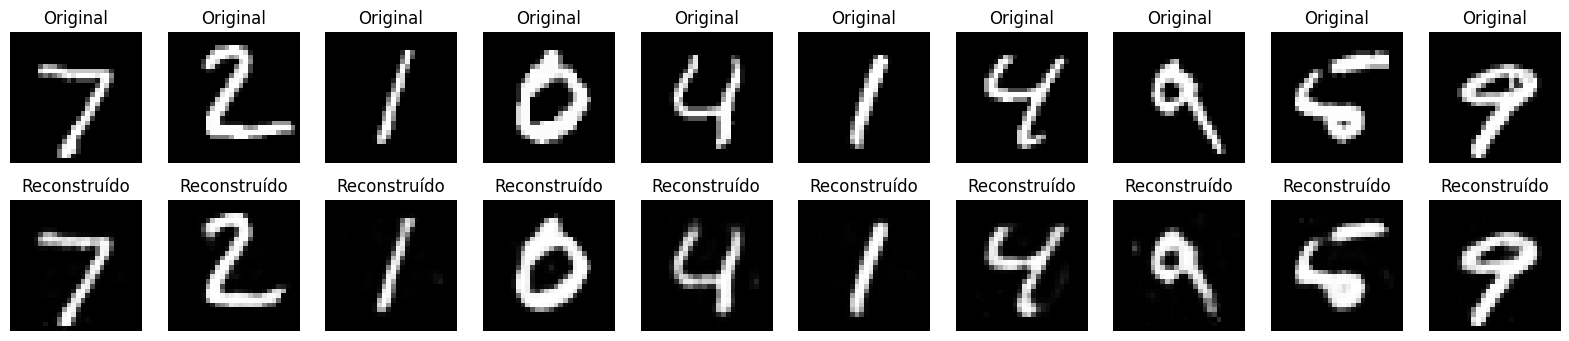

In [ ]:
# Reconstruir algumas imagens do conjunto de teste
decoded_imgs = autoencoder.predict(x_test)

# Função para plotar imagens originais e reconstruídas
def plot_reconstructed_images(original, reconstructed, n=10):
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Plotar imagens originais
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Plotar imagens reconstruídas
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.title("Reconstruído")
        plt.axis('off')
    plt.show()

# Mostrar imagens originais e reconstruídas
plot_reconstructed_images(x_test, decoded_imgs)


# Compressão de imagens

O código abaixo configura e treina um autoencoder para compressão e reconstrução de imagens. O codificador transforma as imagens de entrada, com tamanho 28x28 pixels, em uma representação compacta de 32 dimensões.
O decodificador reconstrói as imagens a partir dessa representação compacta. Começa aumentando a dimensionalidade através de camadas densas, até recuperar o formato original das imagens (28x28 pixels). A função de ativação sigmoid é utilizada para garantir que os valores reconstruídos estejam no intervalo de 0 a 1, similar às imagens originais.

Depois de definir a arquitetura do autoencoder, o modelo é compilado utilizando o otimizador Adam e a função de perda binary_crossentropy, apropriada para a reconstrução de imagens binárias. O treinamento é realizado por 50 épocas, com o conjunto de dados de treinamento, e validado com o conjunto de teste para ajustar os pesos do modelo e minimizar a perda de reconstrução.








In [ ]:
# Definir o autoencoder
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Flatten()(input_img)
encoded = Dense(128, activation='relu')(x)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)  # Camada comprimida

# Decoder
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(28*28, activation='sigmoid')(decoded)
decoded = Reshape((28, 28, 1))(decoded)

# Construir o modelo autoencoder
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Treinar o autoencoder
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# Separar encoder
encoder = Model(input_img, encoded)

# Usar o autoencoder para comprimir e reconstruir as imagens de teste
encoded_imgs = encoder.predict(x_test)
reconstructed_imgs = autoencoder.predict(x_test)


Epoch 1/50
235/235 [==============================] - 6s 7ms/step - loss: 0.2522 - val_loss: 0.1732
Epoch 2/50
235/235 [==============================] - 2s 7ms/step - loss: 0.1552 - val_loss: 0.1408
Epoch 3/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1349 - val_loss: 0.1268
Epoch 4/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1238 - val_loss: 0.1189
Epoch 5/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1176 - val_loss: 0.1138
Epoch 6/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1133 - val_loss: 0.1105
Epoch 7/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1098 - val_loss: 0.1065
Epoch 8/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1067 - val_loss: 0.1049
Epoch 9/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1043 - val_loss: 0.1022
Epoch 10/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1024 - val_loss: 0.1007

## Teste

Tamanho original: 784 dimensões
Tamanho comprimido: 32 dimensões
Taxa de compressão: 24.50


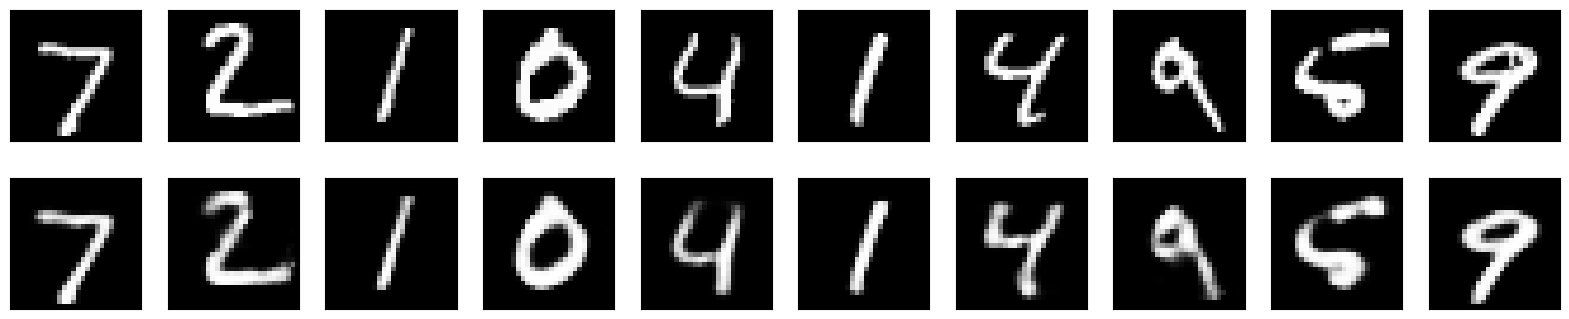

In [ ]:
# Calcular e imprimir a taxa de compressão
original_size = 28 * 28  # 784 dimensões
compressed_size = 32  # tamanho da camada comprimida
compression_ratio = original_size / compressed_size
print(f'Tamanho original: {original_size} dimensões')
print(f'Tamanho comprimido: {compressed_size} dimensões')
print(f'Taxa de compressão: {compression_ratio:.2f}')

# Plotar as imagens originais e as reconstruídas
n = 10  # número de dígitos para exibir
plt.figure(figsize=(20, 4))
for i in range(n):
    # Mostrar imagem original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Mostrar imagem reconstruída
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


# Conclusão
Os autoencoders são eficazes para a compressão e reconstrução de imagens. Através da implementação e treinamento do modelo, foi possível reduzir a dimensionalidade das imagens mantendo a integridade das características essenciais. A capacidade do autoencoder em reconstruir imagens com boa fidelidade a partir de representações comprimidas mostra sua utilidade tanto para a compressão de dados quanto para a reconstrução de imagens. Esses resultados destacam os autoencoders em aplicações práticas de processamento de imagem.






